# ④ 강조색 후보 비교 — `bollard` 색을 무엇으로 할 것인가

> 대상 코드: `scripts/emphasize.py` 의 `PALETTE` (클래스 → BGR 경계선 색)
> 클래스: `0 person` · `1 stairs` · `2 bollard` (8/22 회의 최종 확정)

## 무엇을 정하는가

④ 는 검출 박스의 **경계선만** 이중 스트로크(검정 밑선 + 대비색 본선)로 그리고 내부는
원본을 그대로 둔다. 그 **본선 색**을 클래스마다 정하는 것이 여기서 할 일이다.

저시력·야맹 사용자는 테두리 **색**으로 "앞에 있는 것이 무엇인가"를 판별하므로
이건 미관이 아니라 **기능 요건**이다
(→ [STATUS 3장 함정 16](../docs/STATUS.md) · [share 7-0](../docs/share_yolo_c4b_20260803.md)).

## ✅ 2026-08-24 — 색은 확정됐다

| 클래스 | 색 | HEX |
|---|---|---|
| `person` | 시안 | `#00E6FF` |
| `stairs` | 노랑 (기존 유지) | `#FFD700` |
| **`bollard`** | **라임** | **`#9CFF2E`** |

`scripts/emphasize.py` 의 `PALETTE` 에 이미 반영돼 있고, 이 노트북은 이제
**그 결정이 어떻게 보이는지 확인하고 나중에 다시 저울질할 때 쓰는 자**다.
아래 `CANDIDATES` 의 첫 줄이 채택안이고 나머지는 비교용으로 남긴다.

⚠️ **채택안의 알려진 절충** — 4절이 보여 주듯 `lime` 은 **적록색약에서 `stairs`(노랑)와
가까워진다**(녹색맹 최소 ΔE **9.9** · 적색맹 20.5). 대신 야간 배경 대비를 샀다(5절).
**`P1` 실기기 가독성 검증에서 이 축을 반드시 확인할 것.**

## 색 제약 — 이미 정해져 있는 것 (`emphasize.py` docstring 근거)

| 제약 | 이유 |
|---|---|
| **빨강 금지** | 휘도가 낮아 야간 배경에 묻히고, 적록색약에서 구분이 무너진다 |
| **깜빡임 금지** | 대상 사용자가 광과민이다. 점멸·펄스 강조는 안전 이슈 |
| **비채움** | 내부를 칠하면 잔존시력이 보는 원본 정보를 가린다 |
| **이중 스트로크** | 단색 선은 배경 밝기에 따라 사라진다 — 밑선이 양쪽 대비를 만든다 |

즉 남은 자유도는 **본선 색상(hue)** 뿐이고, 노랑·시안과 **색상·휘도 양쪽에서** 갈리면서
야간 배경 위에서 안 묻히는 색을 찾는 문제다.

## ⚠️ 이 노트북은 판정이 아니다

여기서 보는 것은 **야간 실촬영 7장 + 합성 저조도 2단**뿐이고, 실제 사용 조건(실기기 화면 ·
야외 휘도 · 사용자 시각)은 재현되지 않는다. **최종 확정은 `P1` 실기기 가독성 검증과 묶어
한다** — 이 노트북은 후보를 좁히고 근거를 남기는 자다.

## 실행 조건

- **3번 셀의 `CANDIDATES` 하나만 고치면** 조합을 몇 개든 늘릴 수 있다.
  `assert` 가 첫 줄(채택안)과 `emphasize.PALETTE` 가 어긋나면 막는다.
- 가중치는 3클래스면 무엇이든 된다. 우선순위대로 찾는다 —
  `outputs/detect/c4e_s3_11n`(자체·권장) → `outputs/detect/c4d_11n_640` →
  `outputs/bammasil_results/bammasil_weights/c4d_11n_640`(인수분 · GPU 없는 PC 에 있는 것).
  하나도 없으면 2·3절만 건너뛰고 나머지는 그대로 돈다.
- GPU 없어도 된다 — `DEVICE` 를 자동으로 잡는다.

> ⚠️ **작업 디렉토리는 `notebooks/` 로 둘 것.** 데이터 경로를 `../` 로 잡는다.

In [1]:
import os
import sys
from pathlib import Path

os.environ["YOLO_AUTOINSTALL"] = "false"   # 함정 9: ultralytics 가 onnxruntime CPU 판을 몰래 끼워 넣는다

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한국어 Windows 콘솔(cp949) 대비 (함정 12). Jupyter 커널은 reconfigure 가 없을 수 있다.
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(errors="replace")

ROOT = Path.cwd().parent
assert (ROOT / "scripts").is_dir(), f"작업 디렉토리를 notebooks/ 로 둘 것 (현재: {Path.cwd()})"
sys.path.insert(0, str(ROOT / "scripts"))

from emphasize import (Detection, FALLBACK_COLOR, PALETTE,  # noqa: E402
                       draw_emphasis, from_ultralytics, stroke_width)
from lowlight import build as build_arm                     # noqa: E402

REAL = ROOT / "data/test_real_data"
VARIANTS = {                       # 표시용 이름은 ASCII (matplotlib 한글 폰트 미설정)
    "original": REAL,
    "lowlight(0.35)": REAL / "lowlight",
    "lowlight_x02(0.20)": REAL / "lowlight_x02",
}
OUT = ROOT / "outputs/emphasis_palette"      # 함정 7: 산출물은 outputs/ (git 비추적)
OUT.mkdir(parents=True, exist_ok=True)

# 라벨이 없다 — 장면 구성은 접미사로 가른다 (eval_real_night.py 의 SCENE 과 같은 매핑).
SCENE = {"_04": "bollard x2", "_05": "stairs"}
STEMS = sorted(p.stem for p in REAL.glob("*.jpg"))
CLS3 = ("person", "stairs", "bollard")
IMGSZ, CONF = 640, 0.25          # 배포 640 고정 · 단일 conf 0.25 확정 (C4e S1)
DISP_LONG = 960                  # 표시·렌더 해상도. 원본은 3060x4080 세로라 그대로 그리면 무겁다


def scene_of(stem):
    for suffix, name in SCENE.items():
        if stem.endswith(suffix):
            return name
    return "negative"


def load_image(path):
    '''비ASCII 경로에서도 열리는 RGB 로더 (함정 12 — cv2.imread 는 한글 경로를 못 연다).'''
    img = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def fit(rgb, long_px=DISP_LONG):
    h, w = rgb.shape[:2]
    s = long_px / max(h, w)
    return cv2.resize(rgb, (round(w * s), round(h * s)), interpolation=cv2.INTER_AREA)


def show(ax, rgb, title="", note=""):
    '''title 은 열 머리(첫 행에만), note 는 이미지 안에 얹는 행 정보.

    격자가 넓어 제목을 칸마다 달면 열끼리 겹친다. 열 = 팔레트, 행 = 밝기이므로
    팔레트명은 첫 행 제목으로, 밝기·검출 요약은 첫 열 이미지 안에 둔다.
    '''
    ax.imshow(rgb)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=9)
    if note:
        ax.text(0.02, 0.02, note, transform=ax.transAxes, fontsize=7,
                color="white", va="bottom", ha="left", linespacing=1.3,
                bbox=dict(facecolor="black", alpha=0.65, pad=2.5, edgecolor="none"))


def save(fig, name):
    p = OUT / name
    fig.savefig(p, dpi=110, bbox_inches="tight", facecolor="white")
    print(f"저장: {p.relative_to(ROOT)}")


print(f"이미지 {len(STEMS)}장 · 밝기 {len(VARIANTS)}단 · 표시 {DISP_LONG}px")
print("장면:", {s[-3:]: scene_of(s) for s in STEMS})
print("현 배포 PALETTE:", PALETTE, "· FALLBACK:", FALLBACK_COLOR)

이미지 7장 · 밝기 3단 · 표시 960px
장면: {'014': 'negative', '_01': 'negative', '_02': 'negative', '_03': 'negative', '_04': 'bollard x2', '_05': 'stairs', '_06': 'negative'}
현 배포 PALETTE: {'stairs': (0, 215, 255), 'person': (255, 230, 0), 'bollard': (46, 255, 156)} · FALLBACK: (255, 255, 255)


In [2]:
import torch
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else "cpu"

# 3클래스면 무엇이든 된다 — 있는 것을 우선순위대로 집는다.
WEIGHT_CANDIDATES = [
    ROOT / "outputs/detect/c4e_s3_11n/weights/best.pt",                      # 자체 3클래스 (권장)
    ROOT / "outputs/detect/c4d_11n_640/weights/best.pt",                     # 인수분 복사본
    ROOT / "outputs/bammasil_results/bammasil_weights/c4d_11n_640/best.pt",  # 인수분 원본
]
WEIGHTS = next((p for p in WEIGHT_CANDIDATES if p.exists()), None)

if WEIGHTS is None:
    MODEL = None
    print("⚠️ 3클래스 가중치가 없다 — 2·3절(실제 탐지)은 건너뛴다. 찾아본 곳:")
    for p in WEIGHT_CANDIDATES:
        print("   ", p.relative_to(ROOT))
else:
    MODEL = YOLO(str(WEIGHTS))
    print(f"가중치: {WEIGHTS.relative_to(ROOT)}")
    print(f"클래스 {len(MODEL.names)}종: {MODEL.names}  ·  device={DEVICE}")
    if len(MODEL.names) != 3:
        print("⚠️ 3클래스가 아니다 — bollard 가 안 나오면 1절 합성 박스로만 비교할 것")


def detect_norm(rgb_full, conf=CONF, imgsz=IMGSZ):
    '''**원본 해상도**에서 탐지하고 정규화 좌표로 돌려준다.

    ⚠️ 축소본이 아니라 원본을 먹인다 — detection.md 11-3c 의 야간 볼라드 관측과
    같은 조건이어야 "잡히는 장면"이 재현된다. 정규화라 표시용 축소본에 그대로 얹힌다.
    ultralytics 는 numpy 입력을 BGR 로 해석하므로 채널을 뒤집어 넘긴다.
    '''
    if MODEL is None:
        return []
    r = MODEL.predict(rgb_full[:, :, ::-1], imgsz=imgsz, conf=conf,
                      device=DEVICE, verbose=False)[0]
    h, w = rgb_full.shape[:2]
    return [(d.name, d.conf, (d.box[0] / w, d.box[1] / h, d.box[2] / w, d.box[3] / h))
            for d in from_ultralytics(r)]


def to_dets(norm, shape):
    '''정규화 좌표 → 그 프레임 크기의 `Detection` 목록.'''
    h, w = shape[:2]
    return [Detection(n, c, (round(x1 * w), round(y1 * h), round(x2 * w), round(y2 * h)))
            for n, c, (x1, y1, x2, y2) in norm]


def summarize(norm):
    if not norm:
        return "(no box)"
    got = {}
    for n, c, _ in norm:
        got.setdefault(n, []).append(c)
    return " ".join(f"{k}x{len(v)}({max(v):.2f})" for k, v in sorted(got.items()))

가중치: outputs\bammasil_results\bammasil_weights\c4d_11n_640\best.pt
클래스 3종: {0: 'person', 1: 'stairs', 2: 'bollard'}  ·  device=cpu


C:\Users\playdata2\Documents\KDT_Hackathon\.venv\Lib\site-packages\torch\cuda\__init__.py:188: UserWarning: cudaGetDeviceCount() returned cudaErrorNotSupported, likely using older driver or on CPU machine (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:88.)
  return torch._C._cuda_getDeviceCount() > 0


## ★ 후보 정의 — **여기만 고치면 조합이 늘어난다**

팔레트 이름 → `{클래스: HEX}` 다. HEX 로 적고 `hex_to_bgr()` 로 바꾼다 —
`emphasize.PALETTE` 는 **BGR 튜플**이라 손으로 적으면 R 과 B 가 뒤집힌 것을 눈치채기 어렵다.

`person`·`stairs` 도 같은 딕셔너리에 있으므로 **셋을 통째로 바꾼 조합**도 한 줄 추가하면 된다.

### 후보 목록

- ★ **`adopted (lime)`** — **채택안**(8/24). `emphasize.PALETTE` 와 같아야 하고 `assert` 가 지킨다.
  고휘도라 야간 배경에서 안 묻히고 시안과 확실히 갈린다. **대가는 적록색약에서 노랑과
  가까워지는 것**(4절) — 알고 고른 절충이다.
- **`prev (white fb)`** — 이전 상태. `bollard` 항목이 없어 `FALLBACK_COLOR`(흰색)로 떨어지던
  그림이다. 무엇이 나아졌는지 대조용으로 남긴다. ⚠️ 흰색은 fallback 과 같은 값이라
  **모르는 클래스와도 구분되지 않는다** — 되돌릴 색이 아니다.
- **`alt magenta`** — 색상환에서 노랑·시안과 가장 멀다. 색 구분은 좋으나 야간 대비가 낮다.
- **`alt orange`** — 위험 관례색이나 **노랑과 인접**하고 휘도가 노랑보다 낮다.
- **`alt violet`** — 색각이상 ΔE 1위. 다만 저휘도라 "빨강 금지"의 이유에 가장 가깝다.

저장: outputs\emphasis_palette\0_swatches.png


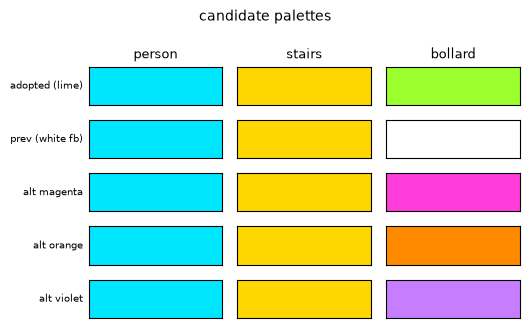

In [3]:
# ★ 채택안 (2026-08-24 확정) — emphasize.PALETTE 와 같아야 한다. 아래 assert 가 지킨다.
ADOPTED = "adopted (lime)"
BASE = {"person": "#00E6FF", "stairs": "#FFD700", "bollard": "#9CFF2E"}

CANDIDATES: dict[str, dict[str, str]] = {
    ADOPTED:           BASE,
    "prev (white fb)": {**BASE, "bollard": "#FFFFFF"},   # 이전 상태 (fallback 으로 떨어지던 색)
    "alt magenta":     {**BASE, "bollard": "#FF3CDC"},
    "alt orange":      {**BASE, "bollard": "#FF8A00"},
    "alt violet":      {**BASE, "bollard": "#C77DFF"},
}


def hex_to_bgr(h):
    h = h.lstrip("#")
    r, g, b = (int(h[i:i + 2], 16) for i in (0, 2, 4))
    return (b, g, r)


def hex_to_rgb(h):
    b, g, r = hex_to_bgr(h)
    return (r, g, b)


def to_palette(spec):
    '''{클래스: HEX} → draw_emphasis(palette=) 가 받는 {클래스: BGR}.'''
    return {k: hex_to_bgr(v) for k, v in spec.items()}


# 채택안이 실제 배포 색과 어긋나면 이 노트북의 비교가 통째로 거짓말이 된다.
assert to_palette(CANDIDATES[ADOPTED]) == PALETTE, (
    f"채택안이 emphasize.PALETTE 와 다르다 — "
    f"{to_palette(CANDIDATES[ADOPTED])} vs {PALETTE}")
assert to_palette(CANDIDATES["prev (white fb)"])["bollard"] == FALLBACK_COLOR


def render(rgb, dets, spec, labels=False):
    '''RGB 프레임에 후보 팔레트로 ④ 강조를 그린다.

    `emphasize` 는 BGR 로 동작하므로 왕복시킨다. 렌더 로직은 재구현하지 않는다 —
    `draw_emphasis(palette=...)` 인자를 그대로 쓴다.
    '''
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    out = draw_emphasis(bgr, dets, min_conf=0.0, labels=labels, palette=to_palette(spec))
    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)


# 후보 스와치 — 배경 없이 색 자체를 먼저 본다
fig, axes = plt.subplots(len(CANDIDATES), 3, figsize=(5.4, 0.66 * len(CANDIDATES)))
for i, (pname, spec) in enumerate(CANDIDATES.items()):
    for j, cname in enumerate(CLS3):
        ax = axes[i, j]
        ax.imshow(np.full((1, 3, 3), hex_to_rgb(spec[cname]), np.uint8), aspect="auto")
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(pname, fontsize=7, rotation=0, ha="right", va="center")
        if i == 0:
            ax.set_title(cname, fontsize=9)
fig.suptitle("candidate palettes", fontsize=10)
fig.tight_layout()
save(fig, "0_swatches.png")
plt.show()

## 1. 색만 본다 — 합성 박스 · 밝기 3단

같은 야간 프레임에 `person`·`stairs`·`bollard` 박스를 **고정 위치**로 얹는다.
배경·위치·두께가 전부 같으므로 셀 사이의 차이는 **오직 색**이다.
탐지 결과에 의존하지 않아 가중치가 없어도 돌고, 세 색이 **한 화면에 같이 있을 때**
서로 갈리는지를 보는 것이 요점이다 — 실제 장면에서는 셋이 동시에 나올 수 있다.

행은 밝기 3단이다. `lowlight`·`lowlight_x02` 는 `scripts/darken.py` 합성본이라
**지표 근거로는 쓰지 않지만**, 강조선이 어두운 배경에서 버티는지를 보는 데는 맞다.

★ **세 클래스가 한 화면에 같이 나오는 것은 이 절뿐이다.** 로컬 소재로는 실사진에서
셋을 동시에 만들 수 없다 — `test_real_data` 는 **사람이 0장**이고(→ [STATUS 4장](../docs/STATUS.md))
AIHub 인도보행 bbox 에는 **`stairs` 가 0건**이다. 실제 `person` 박스는 2b 절에서 본다.

저장: outputs\emphasis_palette\1_synthetic.png


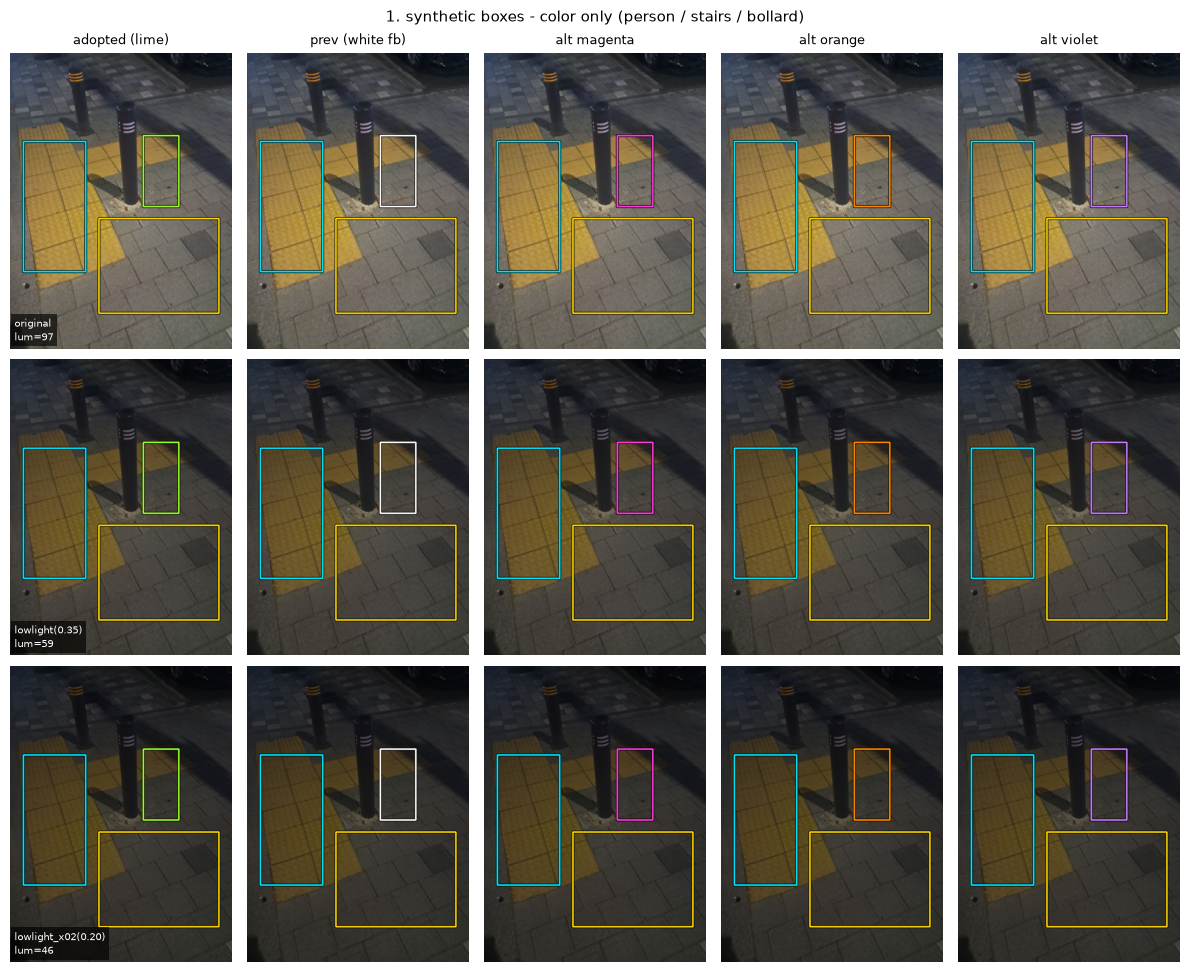

In [4]:
SYN = [   # (클래스, conf, 정규화 xyxy) — 위치는 고정이다
    ("person",  0.86, (0.06, 0.30, 0.34, 0.74)),
    ("stairs",  0.80, (0.40, 0.56, 0.94, 0.88)),
    ("bollard", 0.75, (0.60, 0.28, 0.76, 0.52)),
]
SYN_STEM = next(s for s in STEMS if s.endswith("_04"))   # 야간 볼라드 실사진 배경

fig, axes = plt.subplots(len(VARIANTS), len(CANDIDATES),
                         figsize=(2.4 * len(CANDIDATES), 3.3 * len(VARIANTS)))
for i, (vname, vdir) in enumerate(VARIANTS.items()):
    base = fit(load_image(vdir / f"{SYN_STEM}.jpg"))
    dets = to_dets(SYN, base.shape)
    lum = cv2.cvtColor(base, cv2.COLOR_RGB2GRAY).mean()
    for j, (pname, spec) in enumerate(CANDIDATES.items()):
        show(axes[i, j], render(base, dets, spec),
             title=pname if i == 0 else "",
             note=f"{vname}\nlum={lum:.0f}" if j == 0 else "")
fig.suptitle("1. synthetic boxes - color only (person / stairs / bollard)", fontsize=11)
fig.tight_layout()
save(fig, "1_synthetic.png")
plt.show()

## 2. 실제 탐지 위에서 — 볼라드가 **정말 잡히는 장면**

합성 박스는 색만 보여 주고 실제 박스 크기·위치는 못 보여 준다. 볼라드는 640 환산
폭 중앙값이 7.8px 인 **작은 대상**이라, 박스가 작을 때 두꺼운 이중 스트로크가
대상 자체를 덮어버리지 않는지가 별개의 문제다.

`_04` 는 프로젝트에서 **유일한 야간 볼라드 사진**(2개)이고 `_05` 는 계단이다.
나머지 5장은 음성이라 여기서는 1장만 같이 본다.

⚠️ **탐지는 원본 해상도에서** 돌린다 (`detect_norm`). 표시만 축소본이다.

⚠️ **박스가 하나도 없는 칸이 나오는 것이 정상이다** — `_05`(계단)는 **원본에서만** 잡히고
`gain 0.35` 부터 0개이며, 음성 장면은 애초에 잡힐 것이 없다
(→ [STATUS 2장 4](../docs/STATUS.md) · [detection.md 8-4](../docs/detection.md)).
그런 칸에서는 색 비교가 성립하지 않으니 **1절 합성 박스와 `_04` 를 주로 볼 것.**

⚠️ **이 소재에는 사람이 없다** — `person`(시안) 박스가 한 칸도 안 나온다.
실제 사람 박스는 다음 절(2b)에서 AIHub 소재로 본다.

저장: outputs\emphasis_palette\2_detect__04.png


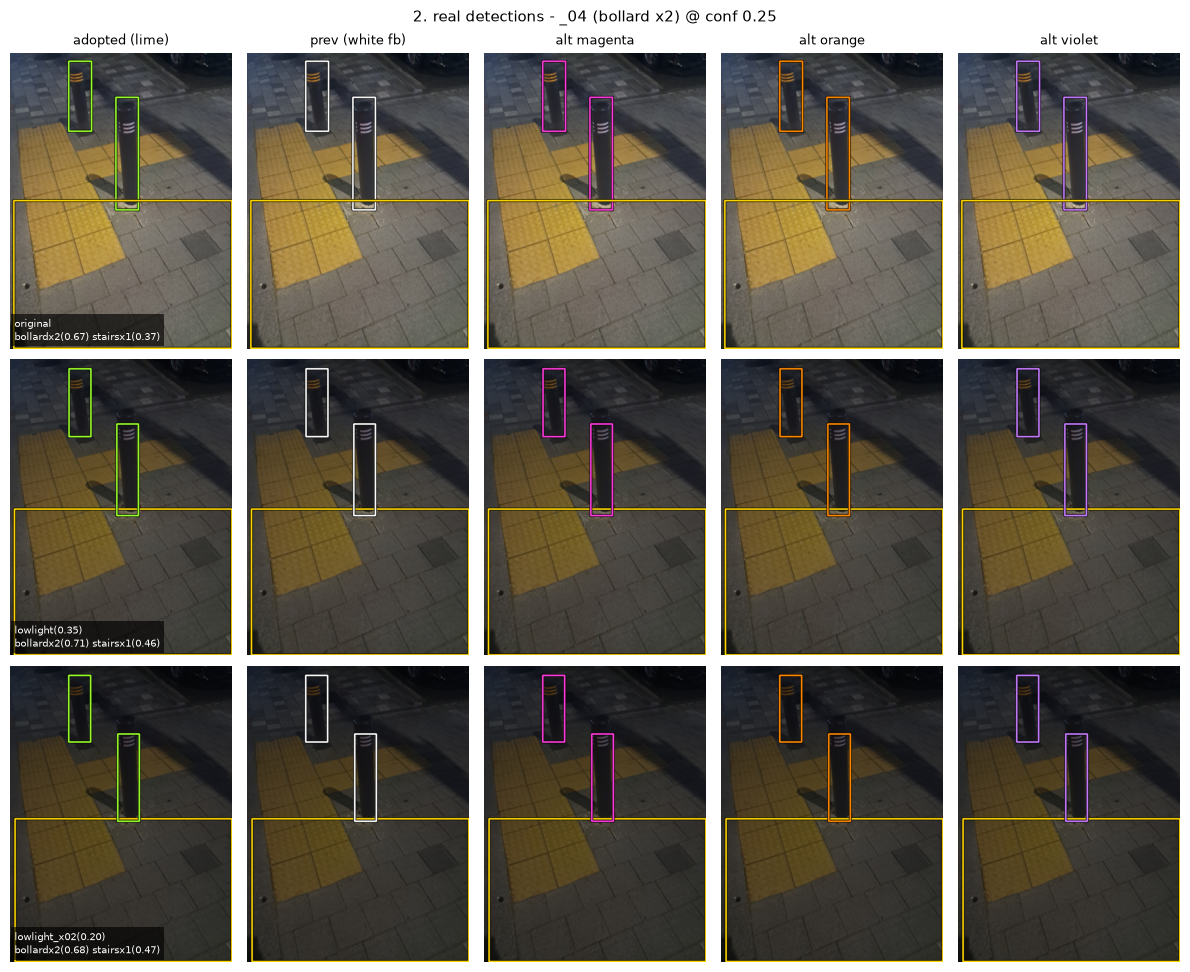

저장: outputs\emphasis_palette\2_detect__05.png


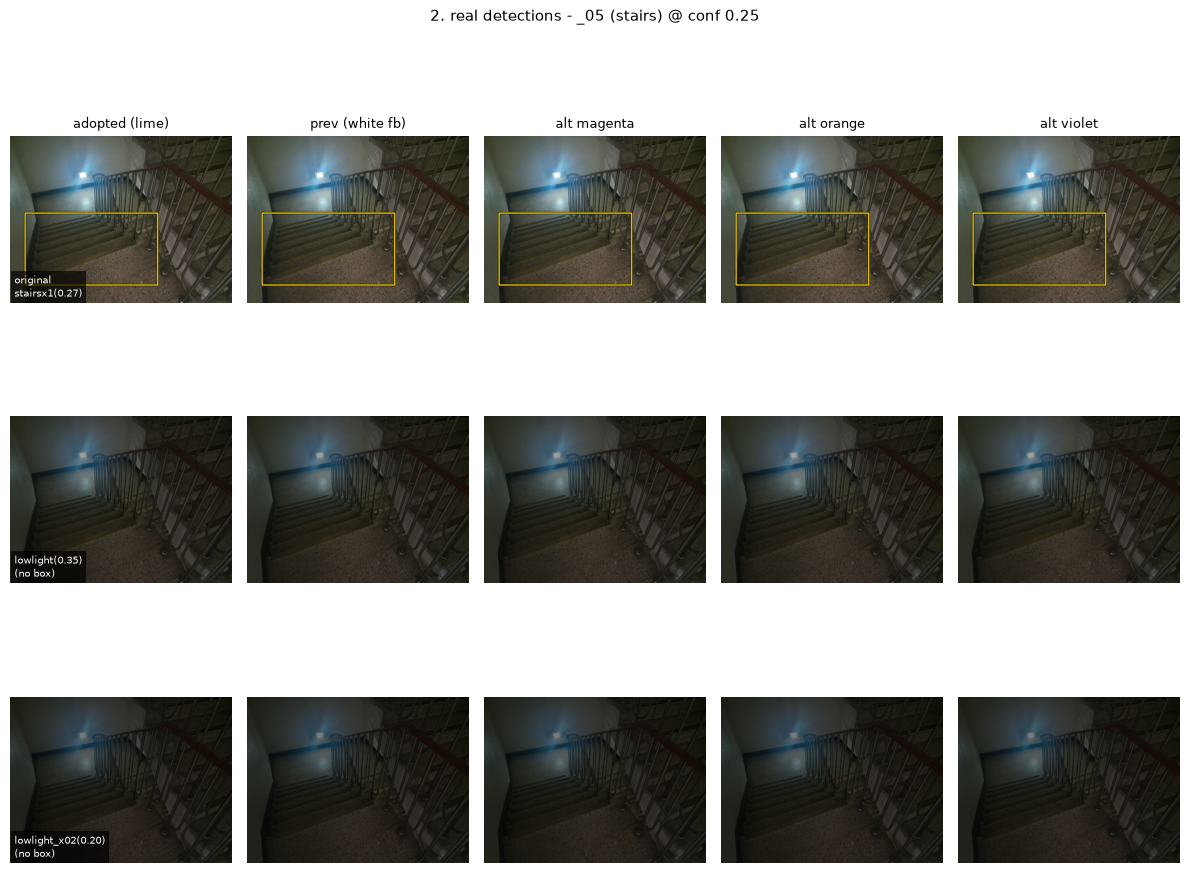

저장: outputs\emphasis_palette\2_detect_014.png


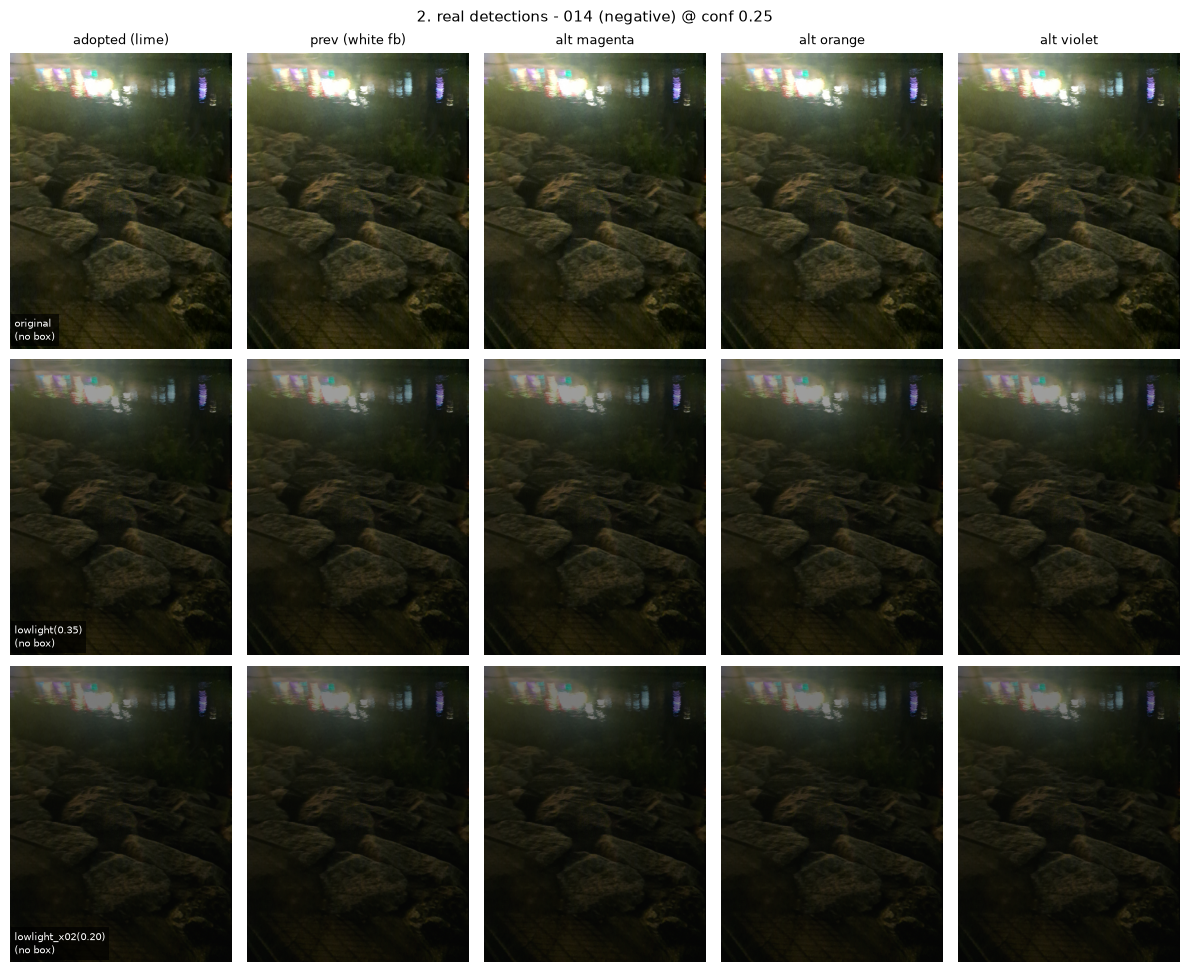

In [5]:
PICK = [next(s for s in STEMS if s.endswith("_04")),
        next(s for s in STEMS if s.endswith("_05")),
        next(s for s in STEMS if scene_of(s) == "negative")]

if MODEL is None:
    print("⚠️ 가중치가 없어 건너뛴다 — 1절 합성 박스로 비교할 것")
else:
    for stem in PICK:
        fig, axes = plt.subplots(len(VARIANTS), len(CANDIDATES),
                                 figsize=(2.4 * len(CANDIDATES), 3.3 * len(VARIANTS)))
        for i, (vname, vdir) in enumerate(VARIANTS.items()):
            full = load_image(vdir / f"{stem}.jpg")
            norm = detect_norm(full)
            disp = fit(full)
            dets = to_dets(norm, disp.shape)
            for j, (pname, spec) in enumerate(CANDIDATES.items()):
                show(axes[i, j], render(disp, dets, spec),
                     title=pname if i == 0 else "",
                     note=f"{vname}\n{summarize(norm)}" if j == 0 else "")
        fig.suptitle(f"2. real detections - {stem[-3:]} ({scene_of(stem)}) @ conf {CONF}",
                     fontsize=11)
        fig.tight_layout()
        save(fig, f"2_detect_{stem[-3:]}.png")
        plt.show()

## 2b. 실제 `person` 박스 — AIHub 인도보행 소재

`test_real_data` 에는 **사람이 한 장도 없다.** 그래서 시안(=`person`)이 실제 박스로
어떻게 보이는지는 위 절에서 확인할 수 없다. 사람과 볼라드가 **같은 프레임에** 있는
실사진은 AIHub 인도보행 서브셋에 있으므로 여기서 가져온다.

**고른 기준** — GT 에 `person`(0)과 `bollard`(2)가 **둘 다** 있고, **실측 평균휘도가 낮은**
프레임이다. ⚠️ 폴더 이름의 `_night`/`_day` 로 고르지 않았다 — 그 분류는 파일 mtime 기반
무효 필드다 (→ [STATUS 3장 함정 13·17](../docs/STATUS.md)).

⚠️ **두 가지를 성능으로 읽지 말 것.**

1. **AIHub 는 이 모델의 학습 도메인**이다. 잘 잡히는 것이 당연하고, 평가 근거가 아니다.
2. **AIHub 는 주간 데이터셋**이다(실측 야간 0.58%). 아래 밝기 3단 중 어두운 둘은
   `scripts/darken.py` 의 `Darkener` 로 **그 자리에서 합성**한 것이라,
   `test_real_data` 의 야간 실촬영과 같은 급의 근거가 아니다.

여기서 볼 것은 딱 하나다 — **시안 `person` 박스가 다른 두 색과 같은 화면에서 갈리는가.**

★ **고른 두 장이 함정 13 의 실물 증거다** — `bollard_day` 폴더에서 나온 쪽이 **실제 야간**
(가로등·간판 광원이 있는 밤거리)이고, `bollard_night` 폴더에서 나온 쪽이 **실제 주간**이다.
정확히 뒤집혀 있다. 그래서 아래 제목에는 폴더명이 아니라 **실측 평균휘도**를 적는다.

저장: outputs\emphasis_palette\2b_aihub_bollard_day.png


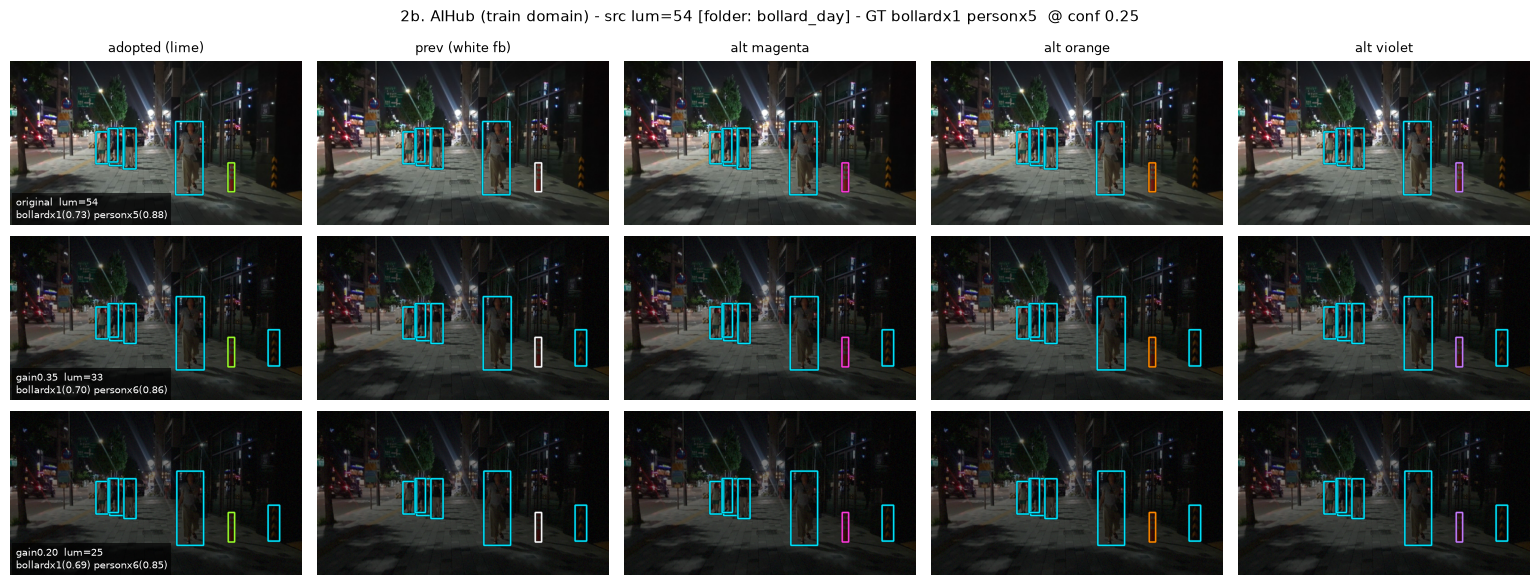

저장: outputs\emphasis_palette\2b_aihub_bollard_night.png


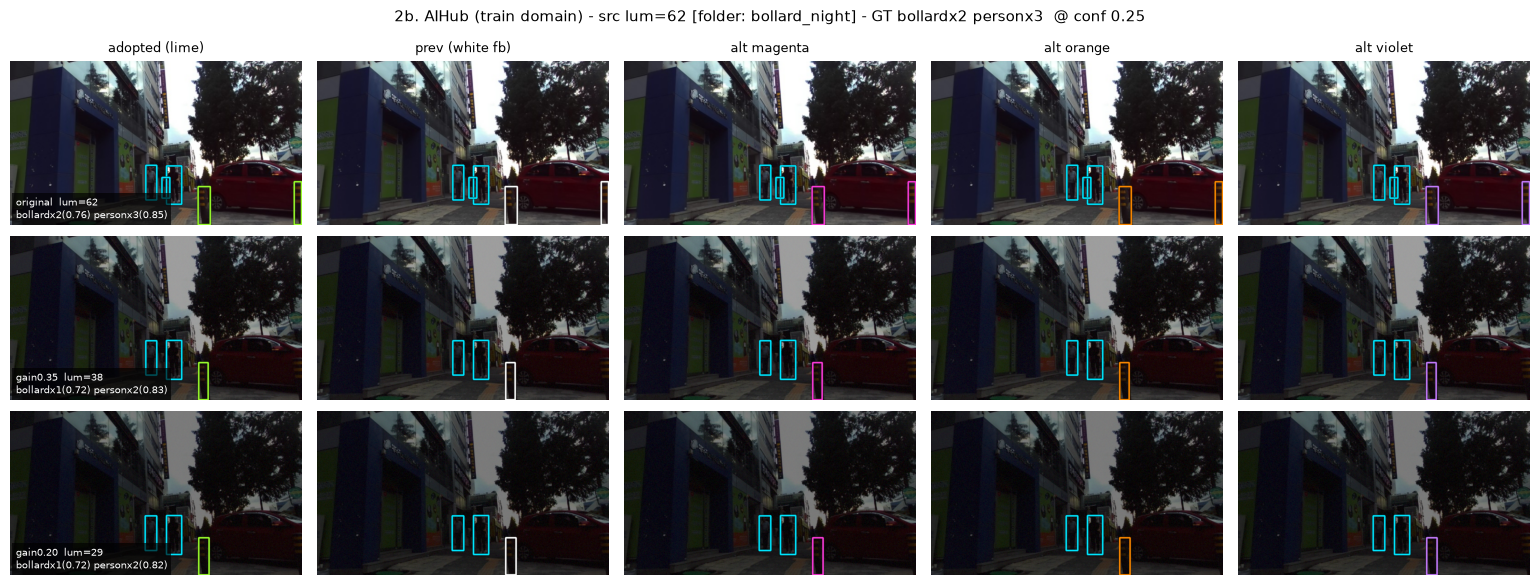

In [6]:
from darken import Darkener   # 원본 → 노출 감소 + 센서 노이즈 (scripts/darken.py 재사용)

AIHUB = ROOT / "data/bammasil_aihub_subset"

# 실측 휘도 하위 + person·bollard 동시 GT 로 고른 프레임 (그룹명이 아니라 휘도로 골랐다).
# 세 밝기 전부에서 person·bollard 가 같이 잡히는 것으로 확인된 2장이다.
AIHUB_PICKS = [
    ("bollard_day", "Bbox_11_new__Bbox_0745__MP_SEL_B044243.jpg"),                  # lum 53.9
    ("bollard_night", "Bbox_21_new__Bbox_1769__ZED1_KSC_014499_L_P002731.jpg"),     # lum 61.8
]
DARKEN = {"original": None, "gain0.35": Darkener(0.35), "gain0.20": Darkener(0.20)}


def aihub_paths(group, fname):
    '''그룹 폴더명으로 (이미지, 라벨) 경로를 찾는다. part1/part2 어디에 있든 잡는다.'''
    for img_root in sorted(AIHUB.glob(f"*_images-*/{group}/images")):
        img = img_root / fname
        if not img.exists():
            continue
        lbl_root = AIHUB / (img_root.parents[1].name.split("_images-")[0] + "_labels")
        return img, lbl_root / group / "labels" / (img.stem + ".txt")
    return None, None


def gt_counts(lbl):
    if lbl is None or not lbl.exists():
        return "(GT 없음)"
    got = {}
    for row in lbl.read_text().splitlines():
        if row.strip():
            name = CLS3[int(row.split()[0])] if int(row.split()[0]) < 3 else "?"
            got[name] = got.get(name, 0) + 1
    return " ".join(f"{k}x{v}" for k, v in sorted(got.items()))


if MODEL is None or not AIHUB.is_dir():
    print("⚠️ 건너뛴다 — 가중치 또는 data/bammasil_aihub_subset 이 없다")
else:
    for group, fname in AIHUB_PICKS:
        img_p, lbl_p = aihub_paths(group, fname)
        if img_p is None:
            print(f"⚠️ 없음: {group}/{fname} — 건너뛴다")
            continue
        src = cv2.cvtColor(load_image(img_p), cv2.COLOR_RGB2BGR)   # Darkener 는 BGR 를 받는다
        src_lum = float(cv2.cvtColor(src, cv2.COLOR_BGR2GRAY).mean())
        fig, axes = plt.subplots(len(DARKEN), len(CANDIDATES),
                                 figsize=(3.1 * len(CANDIDATES), 2.0 * len(DARKEN)))
        for i, (vname, dk) in enumerate(DARKEN.items()):
            bgr = src if dk is None else dk(src)
            full = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            norm = detect_norm(full)
            disp = fit(full)
            dets = to_dets(norm, disp.shape)
            for j, (pname, spec) in enumerate(CANDIDATES.items()):
                show(axes[i, j], render(disp, dets, spec),
                     title=pname if i == 0 else "",
                     note=f"{vname}  lum={cv2.cvtColor(disp, cv2.COLOR_RGB2GRAY).mean():.0f}"
                          f"\n{summarize(norm)}" if j == 0 else "")
        # ⚠️ 폴더명(_day/_night)이 아니라 실측 휘도를 적는다 — 그 분류는 무효 필드다(함정 13)
        fig.suptitle(f"2b. AIHub (train domain) - src lum={src_lum:.0f} "
                     f"[folder: {group}] - GT {gt_counts(lbl_p)}  @ conf {CONF}",
                     fontsize=11)
        fig.tight_layout()
        save(fig, f"2b_aihub_{group}.png")
        plt.show()

## 3. ② 표시 경로 위에서 — 화면에 실제로 나가는 그림

⚠️ **여기가 실제와 같은 조건이다.** 파이프라인은 표시/탐지 2경로다 —
**탐지는 원본**을 먹고, **표시는 ② 처리본**이다 (→ [STATUS 1장](../docs/STATUS.md) ·
`scripts/pipeline_demo.py:128`). ④ 강조선이 얹히는 바닥은 원본이 아니라 **② `D1A1+bf`
통과 프레임**이므로, 색 판단도 그 위에서 해야 맞다.

②는 하이라이트를 누르고 국소 대비를 올리므로 **배경 밝기 분포가 바뀐다** — 원본에서
잘 보이던 색이 여기서 묻힐 수 있다. 그 차이를 보는 절이다.

아래 셀은 **탐지는 원본에서, 렌더는 ② 처리본에** 그린다. 순서를 바꾸면(②를 탐지 앞단에
두면) `stairs` 야간 오탐이 0.1% → 5.7% 로 되살아난다 (`C7`).

저장: outputs\emphasis_palette\3_display_path.png


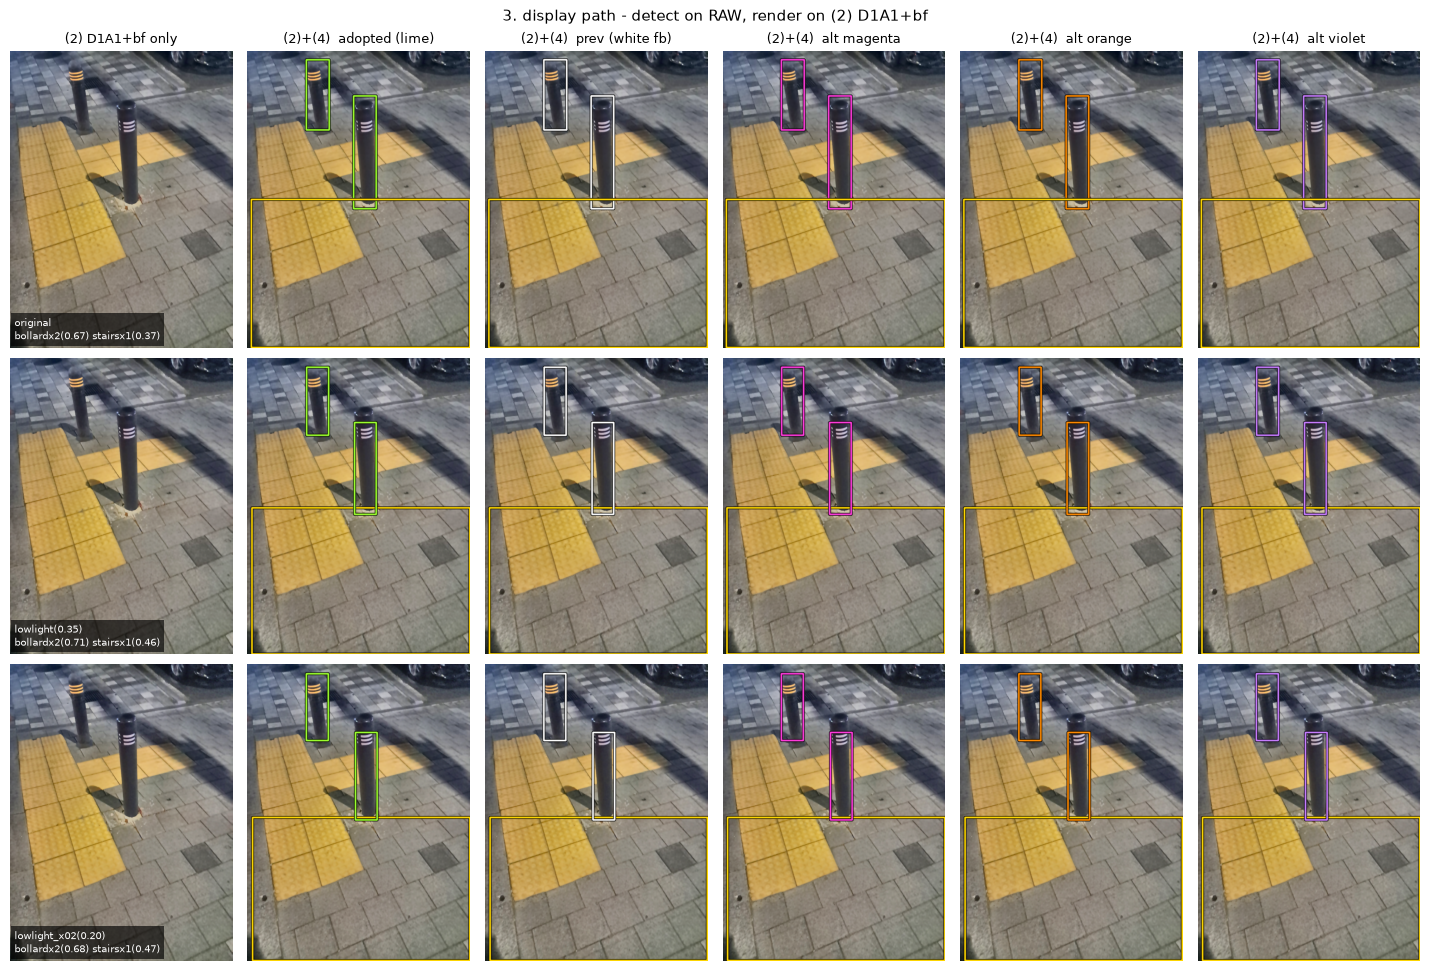

In [7]:
ARM_NAME = "D1A1+bf"
ARM = build_arm(ARM_NAME)
STEM3 = next(s for s in STEMS if s.endswith("_04"))

if MODEL is None:
    print("⚠️ 가중치가 없어 건너뛴다")
else:
    ncol = len(CANDIDATES) + 1
    fig, axes = plt.subplots(len(VARIANTS), ncol,
                             figsize=(2.4 * ncol, 3.3 * len(VARIANTS)))
    for i, (vname, vdir) in enumerate(VARIANTS.items()):
        full = load_image(vdir / f"{STEM3}.jpg")
        norm = detect_norm(full)                       # ★ 탐지는 원본에서
        disp = fit(full)
        shown = cv2.cvtColor(ARM(cv2.cvtColor(disp, cv2.COLOR_RGB2BGR)),
                             cv2.COLOR_BGR2RGB)        # ★ 표시는 ② 처리본
        dets = to_dets(norm, shown.shape)
        show(axes[i, 0], shown,
             title=f"(2) {ARM_NAME} only" if i == 0 else "",
             note=f"{vname}\n{summarize(norm)}")
        for j, (pname, spec) in enumerate(CANDIDATES.items(), start=1):
            show(axes[i, j], render(shown, dets, spec),
                 title=f"(2)+(4)  {pname}" if i == 0 else "")
    fig.suptitle(f"3. display path - detect on RAW, render on (2) {ARM_NAME}", fontsize=11)
    fig.tight_layout()
    save(fig, "3_display_path.png")
    plt.show()

## 4. 색각이상에서도 갈리는가

"빨강 금지"의 근거 절반이 **적록색약**이었다. 새로 넣는 색도 같은 자를 통과해야 한다.
아래는 protanopia(적색맹)·deuteranopia(녹색맹)·tritanopia(청색맹) 근사 변환이다 —
선형 RGB 에서 3×3 행렬을 곱하는 표준 근사(Machado et al. 2009, severity 1.0)이고
**추가 의존성 없이** numpy 로만 돈다.

보는 법: 각 행(색각 유형)에서 `person`·`stairs`·`bollard` **세 패치가 서로 다른 색으로
남아 있는가**. 두 패치가 같아 보이면 그 후보는 그 유형에서 클래스 구분을 잃는다.
아래 표의 최소 ΔE 가 그것을 수치로 준다.

저장: outputs\emphasis_palette\4_cvd_swatches.png


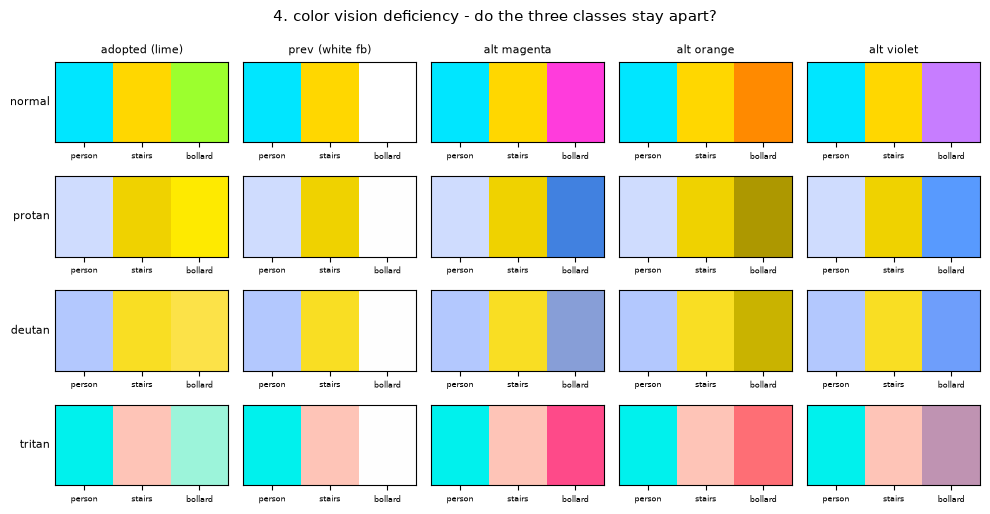

클래스 3색 사이의 최소 ΔE (Lab) — 유형별. 작을수록 두 클래스가 붙는다


,normal,protan,deutan,tritan
palette,,,,
adopted (lime),57.4,20.5,9.9,23.7
prev (white fb),60.6,35.1,56.3,46.8
alt magenta,117.6,93.6,39.1,71.7
alt orange,62.1,57.9,40.8,61.5
alt violet,105.2,73.1,45.1,52.4


In [8]:
# Machado et al. (2009) severity 1.0 — 선형 RGB 공간에서 적용한다
CVD = {
    "protan": np.array([[0.152286, 1.052583, -0.204868],
                        [0.114503, 0.786281, 0.099216],
                        [-0.003882, -0.048116, 1.051998]]),
    "deutan": np.array([[0.367322, 0.860646, -0.227968],
                        [0.280085, 0.672501, 0.047413],
                        [-0.011820, 0.042940, 0.968881]]),
    "tritan": np.array([[1.255528, -0.076749, -0.178779],
                        [-0.078411, 0.930809, 0.147602],
                        [0.004733, 0.691367, 0.303900]]),
}


def srgb_to_linear(x):
    x = np.asarray(x, np.float64) / 255.0
    return np.where(x <= 0.04045, x / 12.92, ((x + 0.055) / 1.055) ** 2.4)


def linear_to_srgb(x):
    x = np.clip(x, 0.0, 1.0)
    s = np.where(x <= 0.0031308, x * 12.92, 1.055 * x ** (1 / 2.4) - 0.055)
    return np.clip(s * 255.0, 0, 255).astype(np.uint8)


def simulate(rgb, kind):
    '''RGB 배열(..., 3) → 해당 색각 유형이 보는 근사색. kind='normal' 이면 그대로.'''
    arr = np.asarray(rgb, np.uint8)
    if kind == "normal":
        return arr
    return linear_to_srgb(srgb_to_linear(arr) @ CVD[kind].T)


KINDS = ["normal", *CVD]

fig, axes = plt.subplots(len(KINDS), len(CANDIDATES),
                         figsize=(2.0 * len(CANDIDATES), 1.3 * len(KINDS)))
for i, kind in enumerate(KINDS):
    for j, (pname, spec) in enumerate(CANDIDATES.items()):
        ax = axes[i, j]
        patch = np.array([[hex_to_rgb(spec[c]) for c in CLS3]], np.uint8)
        ax.imshow(simulate(patch, kind), aspect="auto")
        ax.set_xticks(range(3))
        ax.set_xticklabels(CLS3, fontsize=6)
        ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(kind, fontsize=8, rotation=0, ha="right", va="center")
        if i == 0:
            ax.set_title(pname, fontsize=8)
fig.suptitle("4. color vision deficiency - do the three classes stay apart?", fontsize=11)
fig.tight_layout()
save(fig, "4_cvd_swatches.png")
plt.show()


def to_lab(rgb):
    return cv2.cvtColor(np.array([[rgb]], np.uint8), cv2.COLOR_RGB2LAB)[0, 0].astype(float)


rows = []
for pname, spec in CANDIDATES.items():
    row = {"palette": pname}
    for kind in KINDS:
        labs = [to_lab(simulate(np.array(hex_to_rgb(spec[c]), np.uint8), kind)) for c in CLS3]
        row[kind] = round(min(float(np.linalg.norm(labs[a] - labs[b]))
                              for a in range(3) for b in range(a + 1, 3)), 1)
    rows.append(row)
dE = pd.DataFrame(rows).set_index("palette")
print("클래스 3색 사이의 최소 ΔE (Lab) — 유형별. 작을수록 두 클래스가 붙는다")
display(dE)

## 5. 야간 배경에서 안 묻히는가 — 대비비

"빨강 금지"의 나머지 절반이 **저휘도라 야간 배경에 묻힌다**였다. 같은 축을 수치로 잰다.

각 박스 테두리 **바깥 링의 실제 배경 픽셀**을 뽑아 평균 상대휘도를 구하고, 후보색과의
WCAG 대비비를 낸다. 배경이 장면·밝기마다 다르므로 **밝기 3단 전부**에서 본다.

⚠️ **이중 스트로크라 검정 밑선이 늘 있으므로, 이 수치가 낮다고 선이 사라지지는 않는다.**
낮다는 것은 "본선의 *색*이 배경과 안 갈린다"는 뜻이고, 색으로 클래스를 판별하는 이
설계에서는 그것으로 충분히 문제다. 기준으로 삼을 값은 WCAG 비텍스트 대비 **3:1** 이다.

In [9]:
def rel_lum(rgb):
    '''WCAG 상대휘도. rgb 는 (..., 3) 배열이나 3튜플.'''
    lin = srgb_to_linear(rgb)
    return lin[..., 0] * 0.2126 + lin[..., 1] * 0.7152 + lin[..., 2] * 0.0722


def contrast(l1, l2):
    hi, lo = max(l1, l2), min(l1, l2)
    return (hi + 0.05) / (lo + 0.05)


def ring_lum(rgb, box, pad):
    '''박스 테두리를 감싸는 링의 평균 상대휘도 — 강조선이 실제로 놓이는 배경.'''
    h, w = rgb.shape[:2]
    x1, y1, x2, y2 = box
    mask = np.zeros((h, w), bool)
    mask[max(y1 - pad, 0):min(y2 + pad, h), max(x1 - pad, 0):min(x2 + pad, w)] = True
    mask[max(y1 + pad, 0):max(min(y2 - pad, h), 0),
         max(x1 + pad, 0):max(min(x2 - pad, w), 0)] = False
    if not mask.any():
        return float(rel_lum(rgb).mean())
    return float(rel_lum(rgb[mask]).mean())


rows = []
for vname, vdir in VARIANTS.items():
    base = fit(load_image(vdir / f"{SYN_STEM}.jpg"))
    pad = stroke_width(base) * 2
    for d in to_dets(SYN, base.shape):
        bg = ring_lum(base, d.box, pad)
        for pname, spec in CANDIDATES.items():
            rows.append({
                "class": d.name, "variant": vname, "palette": pname,
                "contrast": round(contrast(
                    float(rel_lum(np.array(hex_to_rgb(spec[d.name])))), bg), 2),
            })

ct = (pd.DataFrame(rows)
      .pivot_table(index=["class", "variant"], columns="palette", values="contrast")
      .reindex(CLS3, level="class"))
print("후보색 vs 박스 주변 배경의 WCAG 대비비 (기준 3:1 · 낮을수록 색이 배경에 묻힌다)")
display(ct)
print("\nbollard 행만 — 이번에 정하는 것")
bo = ct.xs("bollard", level="class")
display(bo)

# 두 축을 한 표로 — 4절(색이 갈리는가)과 5절(배경에서 안 묻히는가)은 서로 다른 것을 잰다.
summary = pd.concat([
    dE[list(CVD)].min(axis=1).rename("min dE (worst CVD)"),
    bo.min(axis=0).rename("min contrast (bollard)"),
], axis=1).sort_values("min dE (worst CVD)", ascending=False)
print("\n두 축 요약 — dE 는 클래스가 갈리는 정도, contrast 는 배경에서 안 묻히는 정도")
display(summary)
print(f"dE 1위: {summary.iloc[:, 0].idxmax()}   ·   대비 1위: {summary.iloc[:, 1].idxmax()}")
if summary.iloc[:, 0].idxmax() != summary.iloc[:, 1].idxmax():
    print("⚠️ 두 축의 1위가 다르다 — 한 색이 둘 다 이기지 않는다. 어느 쪽을 살지가 결정 사항이다.")
print("※ 대비 3:1 은 WCAG 비텍스트 기준이다. dE 에는 그런 표준선이 없어 순위로만 읽을 것.")

후보색 vs 박스 주변 배경의 WCAG 대비비 (기준 3:1 · 낮을수록 색이 배경에 묻힌다)


palette                     adopted (lime)  alt magenta  alt orange  \
class   variant                                                       
person  lowlight(0.35)                5.43         5.43        5.43   
        lowlight_x02(0.20)            7.18         7.18        7.18   
        original                      2.62         2.62        2.62   
stairs  lowlight(0.35)                6.52         6.52        6.52   
        lowlight_x02(0.20)            8.41         8.41        8.41   
        original                      3.28         3.28        3.28   
bollard lowlight(0.35)                7.97         3.30        4.23   
        lowlight_x02(0.20)           10.05         4.16        5.33   
        original                      4.18         1.73        2.22   

palette                     alt violet  prev (white fb)  
class   variant                                          
person  lowlight(0.35)            5.43             5.43  
        lowlight_x02(0.20)        7.18             7.18  
        original                  2.62             2.62  
stairs  lowlight(0.35)            6.52             6.52  
        lowlight_x02(0.20)        8.41             8.41  
        original                  3.28             3.28  
bollard lowlight(0.35)            3.71             9.99  
        lowlight_x02(0.20)        4.68            12.59  
        original                  1.95             5.24


bollard 행만 — 이번에 정하는 것


palette,adopted (lime),alt magenta,alt orange,alt violet,prev (white fb)
variant,,,,,
lowlight(0.35),7.97,3.30,4.23,3.71,9.99
lowlight_x02(0.20),10.05,4.16,5.33,4.68,12.59
original,4.18,1.73,2.22,1.95,5.24



두 축 요약 — dE 는 클래스가 갈리는 정도, contrast 는 배경에서 안 묻히는 정도


,min dE (worst CVD),min contrast (bollard)
palette,,
alt violet,45.1,1.95
alt orange,40.8,2.22
alt magenta,39.1,1.73
prev (white fb),35.1,5.24
adopted (lime),9.9,4.18


dE 1위: alt violet   ·   대비 1위: prev (white fb)
⚠️ 두 축의 1위가 다르다 — 한 색이 둘 다 이기지 않는다. 어느 쪽을 살지가 결정 사항이다.
※ 대비 3:1 은 WCAG 비텍스트 기준이다. dE 에는 그런 표준선이 없어 순위로만 읽을 것.


## 6. 확정된 색 — 코드와 대조

`CHOSEN` 은 기본이 **채택안**이다. 다른 조합으로 갈아탈 일이 생기면 이 값을 바꿔
스니펫을 뽑고 `scripts/emphasize.py` 의 `PALETTE` 에 옮긴다.

⚠️ **이 노트북은 `emphasize.py` 를 자동으로 고치지 않는다.** 색은 사람이 정한다 —
여기까지는 전부 **모니터에서 본 것**이고, 실제 판정 조건(실기기 화면 · 야외 · 사용자
시각)은 `P1` 에서만 재현된다.

🔴 **`P1` 에 넘기는 확인 항목** — 5절 요약이 보여 주듯 두 축(색 구분 · 배경 대비)의 1위가
갈리고, 채택안 `lime` 은 **배경 대비 쪽을 산 선택**이다. 그 대가인 **적록색약에서
`stairs`(노랑)와의 근접**(4절 · 녹색맹 ΔE 9.9)이 실기기·실사용자에서 문제가 되는지가
`P1` 의 판정 대상이다. 문제가 되면 `alt violet`·`alt magenta` 가 되돌아갈 자리다.

In [10]:
CHOSEN = ADOPTED          # ← 다른 조합으로 갈아탈 때만 바꾼다

spec = CANDIDATES[CHOSEN]
print(f"고른 조합: {CHOSEN}"
      + ("   (= 현재 배포값)" if to_palette(spec) == PALETTE else "   ⚠️ 배포값과 다르다")
      + "\n")
print("# scripts/emphasize.py 의 PALETTE 를 이것으로 바꾼다")
print("PALETTE: dict[str, tuple[int, int, int]] = {")
for cname in ("stairs", "person", "bollard"):
    b, g, r = hex_to_bgr(spec[cname])
    print(f'    "{cname}": ({b}, {g}, {r}),'.ljust(34) + f"# {spec[cname]}")
print("}")

if to_palette(spec)["bollard"] == FALLBACK_COLOR:
    print("\n⚠️ bollard 가 FALLBACK_COLOR 와 같은 값이다 —")
    print("   모르는 클래스가 섞여도 구분되지 않으므로 FALLBACK_COLOR 를 먼저 바꿀 것")

print(f"\n비교 이미지: {OUT.relative_to(ROOT)}")
for p in sorted(OUT.glob("*.png")):
    print("   ", p.name)

고른 조합: adopted (lime)   (= 현재 배포값)

# scripts/emphasize.py 의 PALETTE 를 이것으로 바꾼다
PALETTE: dict[str, tuple[int, int, int]] = {
    "stairs": (0, 215, 255),      # #FFD700
    "person": (255, 230, 0),      # #00E6FF
    "bollard": (46, 255, 156),    # #9CFF2E
}

비교 이미지: outputs\emphasis_palette
    0_swatches.png
    1_synthetic.png
    2_detect_014.png
    2_detect__04.png
    2_detect__05.png
    2b_aihub_bollard_day.png
    2b_aihub_bollard_night.png
    3_display_path.png
    4_cvd_swatches.png
